In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statistics
from scipy import stats

pa_gs = pd.read_csv('data/pa_data.csv')

pa_gs_80_95 = pa_gs[pa_gs['year'].between(1980, 1995)]
pa_gs_95_10 = pa_gs[pa_gs['year'].between(1995,2010)]
pa_gs_10_25 = pa_gs[pa_gs['year'].between(2010,2025)]

### Basic Summary Statistics for Whole State GSL

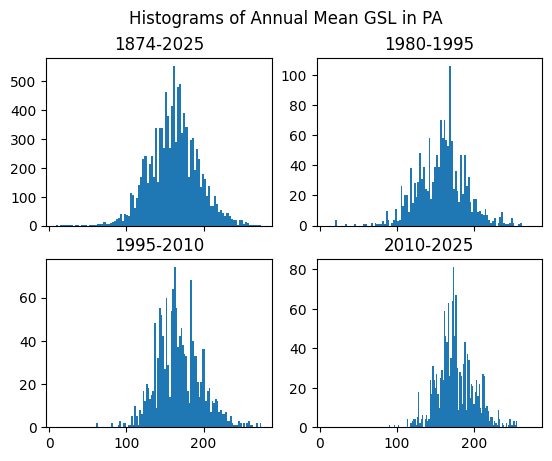

In [20]:
fig, axs = plt.subplots(2,2, sharex=True)
fig.suptitle("Histograms of Annual Mean GSL in PA")
axs[0,0].hist(pa_gs['growing_season_length'], bins = 100)
axs[0,0].set_title("1874-2025")
axs[0,1].hist(pa_gs_80_95['growing_season_length'], bins = 100)
axs[0,1].set_title("1980-1995")
axs[1,0].hist(pa_gs_95_10['growing_season_length'], bins = 100)
axs[1,0].set_title("1995-2010")
axs[1,1].hist(pa_gs_10_25['growing_season_length'], bins = 100)
axs[1,1].set_title("2010-2025")
plt.show()

In [3]:
pa_gs_80_95['growing_season_length'].describe()

count    1571.000000
mean      157.730108
std        32.036599
min        20.000000
25%       137.000000
50%       160.000000
75%       176.000000
max       262.000000
Name: growing_season_length, dtype: float64

In [4]:
pa_gs_95_10['growing_season_length'].describe()

count    1507.000000
mean      168.132714
std        29.045066
min        61.000000
25%       147.000000
50%       165.000000
75%       187.000000
max       275.000000
Name: growing_season_length, dtype: float64

In [21]:
pa_gs_10_25['growing_season_length'].describe()

count    1412.000000
mean      176.174221
std        24.073404
min        89.000000
25%       162.000000
50%       174.000000
75%       192.000000
max       256.000000
Name: growing_season_length, dtype: float64

### Box Plotting for PA, Subsets

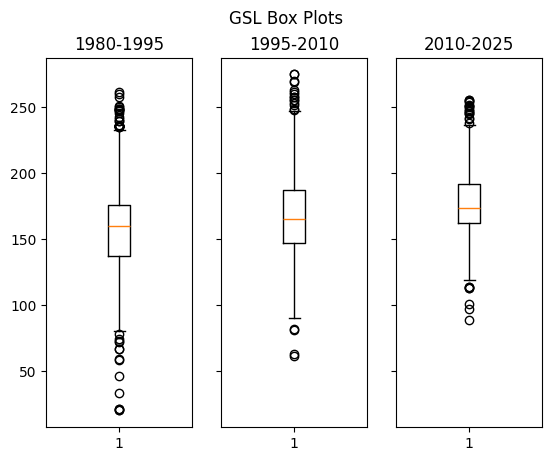

In [22]:
fig, axs = plt.subplots(1,3, sharey=True)
fig.suptitle('GSL Box Plots')
axs[0].boxplot(pa_gs_80_95['growing_season_length'])
axs[0].set_title("1980-1995")
axs[1].boxplot(pa_gs_95_10['growing_season_length'])
axs[1].set_title("1995-2010")
axs[2].boxplot(pa_gs_10_25['growing_season_length'])
axs[2].set_title("2010-2025")
plt.show()

In [35]:
def data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e):
    df1 = data[data['year'].between(yr_int_1_s, yr_int_1_e)]
    df2 = data[data['year'].between(yr_int_2_s, yr_int_2_f)]
    df3 = data[data['year'].between(yr_int_3_s, yr_int_3_e)]
    return df1, df2, df3

coastal_pa_stations = pa_gs[pa_gs['dist_atlantic_km']< 150]
lakeside_pa_stations = pa_gs[pa_gs['dist_greatlakes_km']< 150]
inland_pa_stations = pa_gs[pa_gs['dist_coast_km']>150]
east_pa_stations = pa_gs[pa_gs['longitude'] < -77.569]
west_pa_stations = pa_gs[pa_gs['longitude'] > -77.569]
north_pa_stations = pa_gs[pa_gs['latitude'] > 40.58]
south_pa_stations = pa_gs[pa_gs['latitude'] < 40.58]
low_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] > 371.9]
high_elevation_pa_stations = pa_gs[pa_gs['elevation_m'] <139.9]

subsets = {'Coastal': coastal_pa_stations, 'Inland': inland_pa_stations, 'Lakeside': lakeside_pa_stations, 
           'East': east_pa_stations, 'West': west_pa_stations, 'North': north_pa_stations,
           'South':south_pa_stations, 'Low Elevation':low_elevation_pa_stations, 'High Elevation': high_elevation_pa_stations}

def box_plot_subsets(data, data_name, variable, variable_name, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_e, yr_int_3_s, yr_int_3_e):
    df1, df2, df3 = data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_e, yr_int_3_s, yr_int_3_e)

    fig, axs = plt.subplots(1,3, sharey=True)
    fig.suptitle(f'{data_name} {variable_name} Box Plots')
    axs[0].boxplot(df1[variable])
    axs[0].set_title(f'{yr_int_1_s}-{yr_int_1_e} ({len(df1)} pts)')
    axs[1].boxplot(df2[variable])
    axs[1].set_title(f'{yr_int_2_s}-{yr_int_2_e} ({len(df2)} pts)')
    axs[2].boxplot(df3[variable])
    axs[2].set_title(f'{yr_int_3_s}-{yr_int_3_e} ({len(df3)} pts)')
    plt.show()

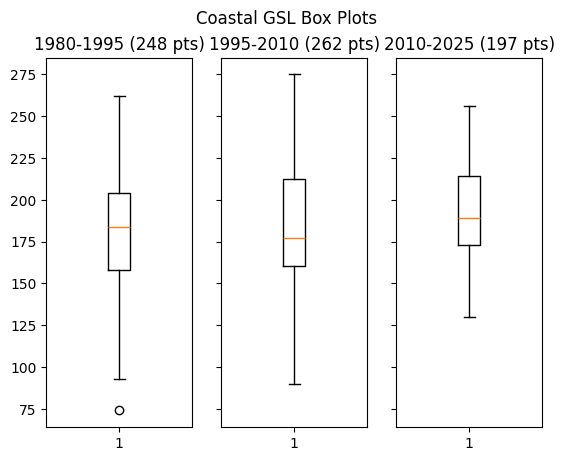

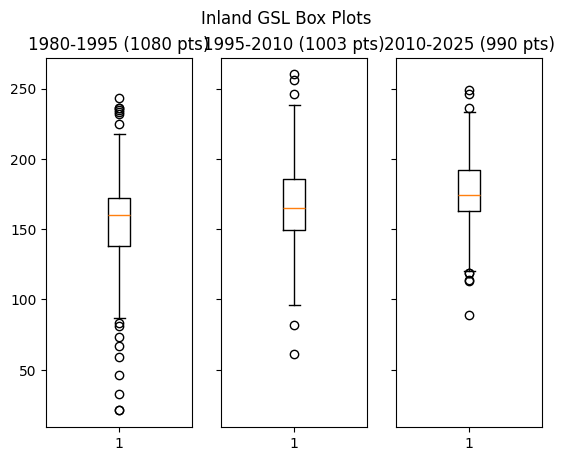

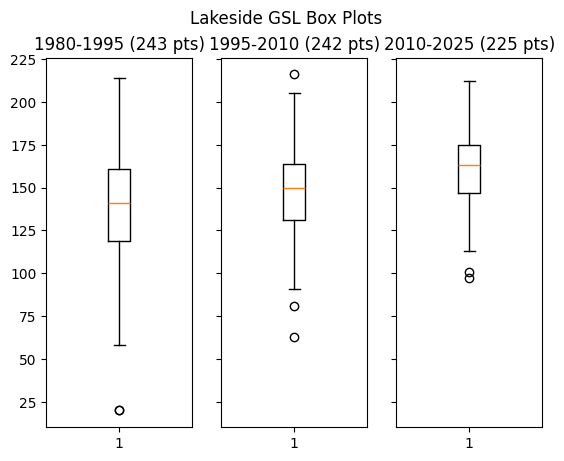

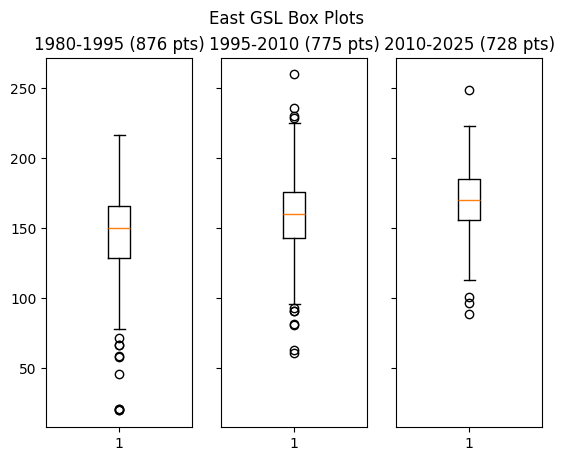

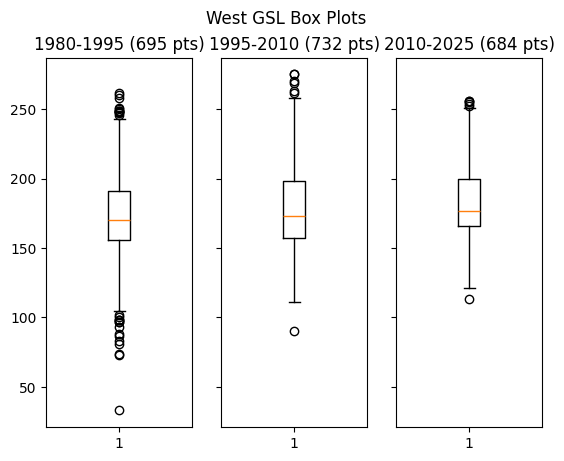

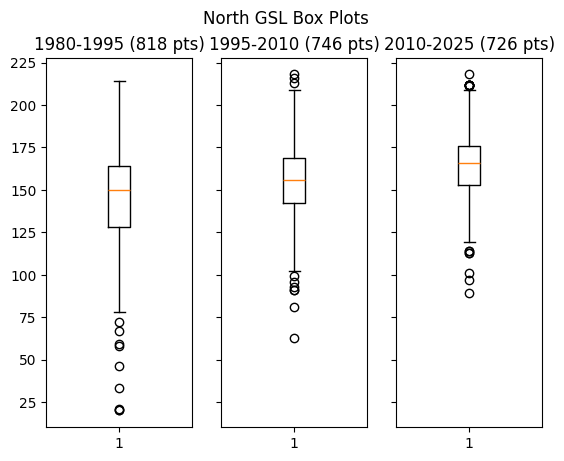

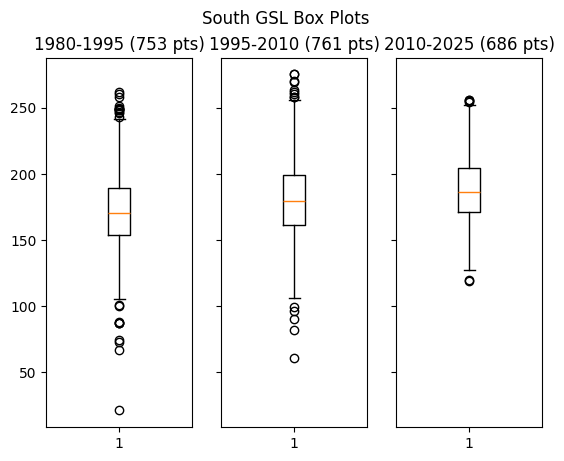

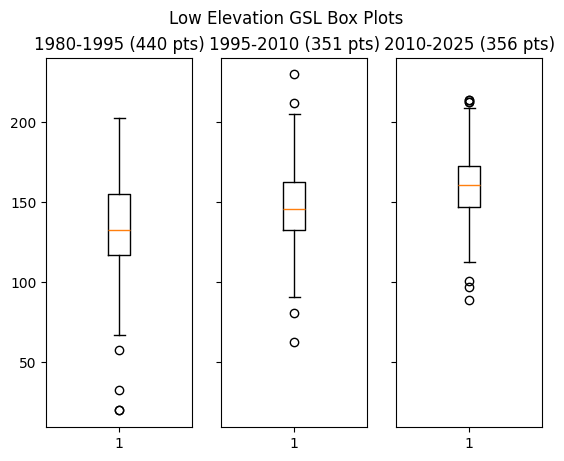

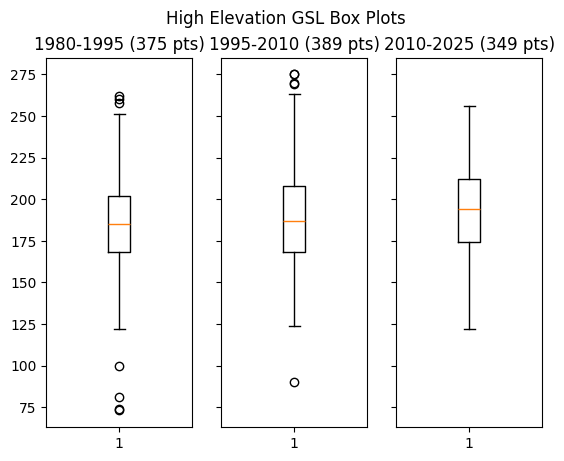

In [36]:
for subset_name, subset in subsets.items():
    box_plot_subsets(subset, subset_name, 'growing_season_length', 'GSL', 1980, 1995, 1995, 2010, 2010, 2025)

### Kruskal Wallis Test

In [28]:
def kruskal_wallis_test(data, variable, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e):

    df1, df2, df3 = data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, yr_int_3_s, yr_int_3_e)

    df1_array = df1[variable].values
    df2_array = df2[variable].values
    df3_array = df3[variable].values

    kw_test = stats.kruskal(df1_array, df2_array, df3_array)

    return kw_test

def F_test_variance(data, variable, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f):

    grp1, grp2, grp3 = data_intervals(data, yr_int_1_s, yr_int_1_e, yr_int_2_s, yr_int_2_f, 0, 0)

    var_1 = statistics.variance(grp1[variable])
    var_2 = statistics.variance(grp2[variable])

    f_value = var_1 / var_2

    deg_fr_1 = len(grp1) - 1
    deg_fr_2 = len(grp2) - 1

    p_value = stats.f.cdf(f_value, deg_fr_1, deg_fr_2)

    readout = f'Degree of freedom 1: {deg_fr_1}, Degree of freedom 2: {deg_fr_2}, F-statistic: {f_value}, p-value: {p_value}'
    return readout

In [10]:
for subset_name, subset in subsets.items():
    kw_test = kruskal_wallis_test(subset, 'growing_season_length', 1980, 1995, 1995, 2010, 2010, 2023)
    print(f'{subset_name} : {kw_test}')

Coastal : KruskalResult(statistic=np.float64(8.753099662533572), pvalue=np.float64(0.012568647856402524))
Inland : KruskalResult(statistic=np.float64(237.2832426134991), pvalue=np.float64(2.982624235495962e-52))
Lakeside : KruskalResult(statistic=np.float64(69.85036833421884), pvalue=np.float64(6.794933906662452e-16))
East : KruskalResult(statistic=np.float64(261.24088767049125), pvalue=np.float64(1.8718111010684398e-57))
West : KruskalResult(statistic=np.float64(34.20771018192155), pvalue=np.float64(3.731557299123553e-08))
North : KruskalResult(statistic=np.float64(204.25785739304942), pvalue=np.float64(4.425576215646101e-45))
South : KruskalResult(statistic=np.float64(94.6749991479016), pvalue=np.float64(2.764299835685523e-21))
Low Elevation : KruskalResult(statistic=np.float64(169.48744554377927), pvalue=np.float64(1.571335145151194e-37))
High Elevation : KruskalResult(statistic=np.float64(11.173739719985017), pvalue=np.float64(0.003746737341426659))


All Subsets have Significant Kruskal-Wallis Test results

### F-Test for Variance

In [11]:
for subset_name, subset in subsets.items():
    f_test = F_test_variance(subset, 'growing_season_length', 1980, 1995, 1995, 2010)
    print(f'{subset_name} : {f_test}')

Coastal : Degree of freedom 1: 247, Degree of freedom 2: 261, F-statistic: 1.056109386346857, p-value: 0.6684610062684739
Inland : Degree of freedom 1: 1079, Degree of freedom 2: 1002, F-statistic: 1.2176594451616112, p-value: 0.9992274536182905
Lakeside : Degree of freedom 1: 242, Degree of freedom 2: 241, F-statistic: 1.375344093671836, p-value: 0.9932111695579867
East : Degree of freedom 1: 875, Degree of freedom 2: 774, F-statistic: 1.2078018448313925, p-value: 0.9964923935907842
West : Degree of freedom 1: 694, Degree of freedom 2: 731, F-statistic: 1.117564914939935, p-value: 0.9310205701124705
North : Degree of freedom 1: 817, Degree of freedom 2: 745, F-statistic: 1.4475813610635389, p-value: 0.9999998561402788
South : Degree of freedom 1: 752, Degree of freedom 2: 760, F-statistic: 1.1419752083276438, p-value: 0.9659378403559367
Low Elevation : Degree of freedom 1: 439, Degree of freedom 2: 350, F-statistic: 1.322481964127745, p-value: 0.9968696810521146
High Elevation : Degre

In [24]:
for subset_name, subset in subsets.items():
    f_test = F_test_variance(subset, 'growing_season_length', 1995, 2010, 2010, 2025)
    print(f'{subset_name} : {f_test}')

Coastal : Degree of freedom 1: 261, Degree of freedom 2: 196, F-statistic: 1.5386790014880585, p-value: 0.9992372766410084
Inland : Degree of freedom 1: 1002, Degree of freedom 2: 989, F-statistic: 1.356160940581808, p-value: 0.9999991823346368
Lakeside : Degree of freedom 1: 241, Degree of freedom 2: 224, F-statistic: 1.5874922503487041, p-value: 0.9997590149604136
East : Degree of freedom 1: 774, Degree of freedom 2: 727, F-statistic: 1.3351330843043105, p-value: 0.9999596404162746
West : Degree of freedom 1: 731, Degree of freedom 2: 683, F-statistic: 1.4845972880243066, p-value: 0.9999999101172135
North : Degree of freedom 1: 745, Degree of freedom 2: 725, F-statistic: 1.4055559168985057, p-value: 0.9999978651461401
South : Degree of freedom 1: 760, Degree of freedom 2: 685, F-statistic: 1.5410086220564536, p-value: 0.9999999957207886
Low Elevation : Degree of freedom 1: 350, Degree of freedom 2: 355, F-statistic: 1.332238483872547, p-value: 0.9964004869985024
High Elevation : Degr

No subset on either set of intervals has F-test significant on p=0.05